## 02 — Shallow Baselines

ทดสอบ classification baselines ทั้งหมดที่ไม่ใช่ neural — เพื่อตั้ง benchmark ก่อนเข้า
neural models ใน notebook 03 ใช้ 6-fold leave-one-piece-out CV × 3 seeds

## เป้าหมายของ notebook นี้

1. ตั้ง CV evaluation pipeline ที่ใช้ได้กับทุก model
2. รัน baselines 0-8 (Random, Majority, LR, RF, NB, SVM × 3, XGBoost)
3. Window length sweep บน best model
4. สรุปผลเป็น CSV เดียวเพื่อใช้ใน Pillar 4 (interpretability) และเป็น reference
   สำหรับ neural models ใน notebook 03

## Baselines ที่จะทดสอบ

| # | Model | Features |
|---|---|---|
| 0 | Random | — |
| 1 | Majority class | — |
| 2 | Logistic Regression | 7 hand-crafted |
| 3 | Random Forest | 7 hand-crafted |
| 4 | Multinomial Naive Bayes | token unigram counts |
| 5 | Linear SVM | token unigram TF-IDF |
| 6 | Linear SVM | token bigram TF-IDF |
| 7 | Linear SVM | token trigram TF-IDF |
| 8 | XGBoost | combined (n-gram + hand-crafted) |

## โครงสร้าง

| Section | หัวข้อ |
|---|---|
| 1 | Setup |
| 2 | CV pipeline + metrics |
| 3 | Baselines 0-1: Random / Majority (floor) |
| 4 | Baselines 2-3: hand-crafted features (LR / RF) |
| 5 | Baselines 4-7: n-gram features (NB / SVM × 3) |
| 6 | Baseline 8: XGBoost combined |
| 7 | Window length sweep |
| 8 | Consolidated results + ranking |

## Output

- `results/tables/all_baselines.csv` — ทุก run (model × fold × seed)
- `results/tables/baseline_summary.csv` — mean ± std per model
- `results/figures/baseline_accuracy.png` — bar chart
- `results/figures/confusion_<best_model>.png` — confusion matrix
- `results/figures/window_sweep.png` — accuracy vs window length

## 1. Setup

โหลด data, refresh src/utils, build windows + features ที่ใช้ใน baselines 2-3 และ 8

In [1]:
import sys
import os
import urllib.request
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/02_FindingInstrument')
else:
    PROJECT_ROOT = Path.cwd().parent

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# ติดตั้ง Thai font สำหรับ matplotlib
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
FONT_PATH = Path('/content/Sarabun-Regular.ttf') if IN_COLAB else Path.home() / 'Sarabun-Regular.ttf'
if not FONT_PATH.exists():
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont(str(FONT_PATH))
plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['axes.unicode_minus'] = False

# Reload src.utils เผื่อแก้ระหว่างทาง
import importlib
import src.utils
importlib.reload(src.utils)

from src.utils import (
    load_notes, build_windows, compute_features_dataframe,
    make_cv_splits, set_seed, save_fig, save_table,
    INSTRUMENTS, PIECES, FEATURE_COLS,
)

import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter

set_seed(42)

# Load + prepare
df = load_notes()
df['section'] = df['section'].fillna('สาธุการ')
windows_df = build_windows(df, window_size=16, stride=8)
features_df = compute_features_dataframe(windows_df)

# สีสำหรับ instrument (consistent กับ notebook 01)
inst_colors = {
    'ขลุ่ย-ปี่':   '#4477aa',
    'ฆ้องวงใหญ่': '#ee7733',
    'ซออู้':       '#228833',
    'ระนาดเอก':    '#cc3366',
}

print(f"✓ data: {len(df):,} bars")
print(f"✓ windows: {len(windows_df)} (size=16, stride=8)")
print(f"✓ features: {features_df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ data: 6,760 bars
✓ windows: 819 (size=16, stride=8)
✓ features: (819, 12)


## 2. CV pipeline + metrics

สร้าง function กลางที่:
1. รับ model + features + labels
2. วนทำ leave-one-piece-out 6-fold × 3 seeds = 18 runs
3. คำนวณ accuracy, macro-F1, per-class F1, confusion matrix
4. คืน 2 อย่าง: result rows (สำหรับ append เข้า CSV) และ aggregated confusion matrix

ทุก baseline จะเรียก function นี้ → ผลเปรียบเทียบกันได้แบบตรง ๆ

In [2]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.base import clone

# Labels ที่ใช้ทั่ว notebook นี้ — convert instrument string เป็น index 0-3
windows_labels = features_df['instrument'].map({inst: i for i, inst in enumerate(INSTRUMENTS)}).values

def evaluate_model(model, X, model_name, seeds=(42, 123, 2024)):
    """รัน leave-one-piece-out 6-fold × seeds, คืน result rows + aggregated confusion matrix

    Parameters
    ----------
    model : sklearn estimator (ต้อง clone ได้)
    X : numpy array หรือ sparse matrix, shape (n_windows, n_features)
    model_name : str — สำหรับ tag ใน result rows
    seeds : tuple of int

    Returns
    -------
    rows : list of dict — แต่ละ row = 1 run (model × fold × seed)
    confusion : np.ndarray (4, 4) — รวมจากทุก fold × seed
    """
    rows = []
    confusion_total = np.zeros((4, 4), dtype=int)

    for seed in seeds:
        for held_out, train_idx, test_idx in make_cv_splits(features_df, group_col='piece'):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = windows_labels[train_idx], windows_labels[test_idx]

            # Clone เพื่อให้แต่ละ run เริ่มจาก fresh model
            clf = clone(model)
            if hasattr(clf, 'random_state'):
                clf.random_state = seed

            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
            f1_per_class = f1_score(y_test, y_pred, average=None,
                                    labels=range(4), zero_division=0)

            rows.append({
                'model':       model_name,
                'seed':        seed,
                'held_out':    held_out,
                'accuracy':    acc,
                'macro_f1':    f1_macro,
                'f1_khlui':    f1_per_class[0],
                'f1_khong':    f1_per_class[1],
                'f1_so':       f1_per_class[2],
                'f1_ranat':    f1_per_class[3],
                'n_train':     len(train_idx),
                'n_test':      len(test_idx),
            })

            confusion_total += confusion_matrix(y_test, y_pred, labels=range(4))

    return rows, confusion_total


def summarize_runs(rows):
    """รับ list of result rows คืน summary row 1 ตัว: mean ± std ของ accuracy + macro_f1"""
    rdf = pd.DataFrame(rows)
    return {
        'model':           rdf['model'].iloc[0],
        'accuracy_mean':   rdf['accuracy'].mean(),
        'accuracy_std':    rdf['accuracy'].std(),
        'macro_f1_mean':   rdf['macro_f1'].mean(),
        'macro_f1_std':    rdf['macro_f1'].std(),
        'f1_khlui_mean':   rdf['f1_khlui'].mean(),
        'f1_khong_mean':   rdf['f1_khong'].mean(),
        'f1_so_mean':      rdf['f1_so'].mean(),
        'f1_ranat_mean':   rdf['f1_ranat'].mean(),
        'n_runs':          len(rdf),
    }


# DataFrames สำหรับเก็บผลทั้ง notebook — append เมื่อแต่ละ baseline เสร็จ
all_rows = []
all_confusion = {}  # {model_name: confusion_matrix}

print("✓ CV pipeline พร้อม")
print(f"  windows_labels shape: {windows_labels.shape}")
print(f"  class distribution: {dict(zip(INSTRUMENTS, np.bincount(windows_labels)))}")

✓ CV pipeline พร้อม
  windows_labels shape: (819,)
  class distribution: {'ขลุ่ย-ปี่': np.int64(194), 'ฆ้องวงใหญ่': np.int64(198), 'ซออู้': np.int64(200), 'ระนาดเอก': np.int64(227)}


## 3. Baselines 0-1: Random / Majority

Baseline ต่ำสุดที่ทุก model ควรชนะ ใช้เป็น sanity check
- **Random:** สุ่มตอบ 1 ใน 4 → คาดว่า ~25%
- **Majority:** ตอบ ระนาดเอก (class ใหญ่สุด) ทุกครั้ง → คาดว่า ~27.6%

In [3]:
from sklearn.dummy import DummyClassifier

# X dummy — DummyClassifier ไม่ใช้ features จริง แต่ต้องส่ง array shape
X_dummy = np.zeros((len(features_df), 1))

# Baseline 0: Random uniform
rows, conf = evaluate_model(
    DummyClassifier(strategy='uniform', random_state=42),
    X_dummy,
    model_name='0_random',
)
all_rows.extend(rows)
all_confusion['0_random'] = conf
print(f"0_random:   acc {pd.DataFrame(rows)['accuracy'].mean():.3f} ± {pd.DataFrame(rows)['accuracy'].std():.3f}")

# Baseline 1: Majority class
rows, conf = evaluate_model(
    DummyClassifier(strategy='most_frequent'),
    X_dummy,
    model_name='1_majority',
)
all_rows.extend(rows)
all_confusion['1_majority'] = conf
print(f"1_majority: acc {pd.DataFrame(rows)['accuracy'].mean():.3f} ± {pd.DataFrame(rows)['accuracy'].std():.3f}")

print(f"\nรวม runs จนถึงตอนนี้: {len(all_rows)}")

0_random:   acc 0.247 ± 0.028
1_majority: acc 0.279 ± 0.050

รวม runs จนถึงตอนนี้: 36


## 4. Baselines 2-3: Hand-crafted features (LR / RF)

ใช้ 7 features จาก notebook 01 (sustain ratio, octave ratios, ลูกสบัด, paren, entropy)
เป็น input ของ 2 model: Logistic Regression และ Random Forest

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# X จาก 7 hand-crafted features
X_handcrafted = features_df[FEATURE_COLS].values

# Baseline 2: Logistic Regression
# ใช้ StandardScaler เพราะ features มี scale ต่างกัน (transition_entropy ~5 vs paren_ratio ~0.01)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, C=1.0, random_state=42))
])
rows, conf = evaluate_model(lr_pipeline, X_handcrafted, model_name='2_lr_handcrafted')
all_rows.extend(rows)
all_confusion['2_lr_handcrafted'] = conf
mean_acc = pd.DataFrame(rows)['accuracy'].mean()
std_acc = pd.DataFrame(rows)['accuracy'].std()
mean_f1 = pd.DataFrame(rows)['macro_f1'].mean()
print(f"2_lr_handcrafted:  acc {mean_acc:.3f} ± {std_acc:.3f}   macro-F1 {mean_f1:.3f}")

# Baseline 3: Random Forest
rows, conf = evaluate_model(
    RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1),
    X_handcrafted,
    model_name='3_rf_handcrafted'
)
all_rows.extend(rows)
all_confusion['3_rf_handcrafted'] = conf
mean_acc = pd.DataFrame(rows)['accuracy'].mean()
std_acc = pd.DataFrame(rows)['accuracy'].std()
mean_f1 = pd.DataFrame(rows)['macro_f1'].mean()
print(f"3_rf_handcrafted:  acc {mean_acc:.3f} ± {std_acc:.3f}   macro-F1 {mean_f1:.3f}")

print(f"\nรวม runs: {len(all_rows)}")

2_lr_handcrafted:  acc 0.611 ± 0.065   macro-F1 0.580
3_rf_handcrafted:  acc 0.548 ± 0.075   macro-F1 0.527

รวม runs: 72


## 5. Baselines 4-7: n-gram features (NB / SVM × 3)

ใช้ token sequence โดยตรง — แต่ละ window เป็น "document" ของ tokens
- **4 NB:** Multinomial Naive Bayes บน unigram counts (baseline classic text)
- **5 SVM unigram:** Linear SVM + TF-IDF บน unigram
- **6 SVM bigram:** + bigram (จับ "หลัง X มา Y" — ลำดับสั้น)
- **7 SVM trigram:** + trigram (ลำดับยาวขึ้น)

จาก Pillar 1 bigram transition heatmap เห็น pattern ต่างกันชัดต่อเครื่อง — คาดว่า
n-gram จะดีกว่า hand-crafted features

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# สร้าง "document" string จาก tokens — คั่นด้วย space เพื่อให้ vectorizer แยก token ได้
docs = (features_df
        .merge(windows_df[['song_file', 'start_bar', 'tokens']],
               on=['song_file', 'start_bar'])
        ['tokens']
        .apply(lambda toks: ' '.join(toks))
        .tolist())

print(f"Documents: {len(docs)}")
print(f"Sample doc: {docs[0][:80]}...")

# Tokenizer: split by whitespace
def thai_token_split(text):
    return text.split()

# Function รัน CV กับ text input — เหมือน evaluate_model แต่รับ list of strings
def evaluate_model_text(pipeline, docs, model_name, seeds=(42, 123, 2024)):
    rows = []
    confusion_total = np.zeros((4, 4), dtype=int)
    docs_arr = np.array(docs, dtype=object)

    for seed in seeds:
        for held_out, train_idx, test_idx in make_cv_splits(features_df, group_col='piece'):
            X_train = docs_arr[train_idx].tolist()
            X_test = docs_arr[test_idx].tolist()
            y_train = windows_labels[train_idx]
            y_test = windows_labels[test_idx]

            clf = clone(pipeline)
            for step_name, step in clf.steps:
                if hasattr(step, 'random_state'):
                    step.random_state = seed

            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
            f1_per_class = f1_score(y_test, y_pred, average=None,
                                    labels=range(4), zero_division=0)

            rows.append({
                'model': model_name, 'seed': seed, 'held_out': held_out,
                'accuracy': acc, 'macro_f1': f1_macro,
                'f1_khlui': f1_per_class[0], 'f1_khong': f1_per_class[1],
                'f1_so': f1_per_class[2], 'f1_ranat': f1_per_class[3],
                'n_train': len(train_idx), 'n_test': len(test_idx),
            })
            confusion_total += confusion_matrix(y_test, y_pred, labels=range(4))

    return rows, confusion_total

print(f"\n✓ evaluate_model_text พร้อม")

Documents: 819
Sample doc: - - - ม - ซ ซ ซ - - - ล - ซ ซ ซ ล ท รํ ม - ซ - ล - - มํ รํ ท - ล - ซ - ล - ท - ด...

✓ evaluate_model_text พร้อม


In [8]:
# Baseline 4: Multinomial NB + unigram counts
nb_pipeline = Pipeline([
    ('vec', CountVectorizer(tokenizer=thai_token_split, token_pattern=None,
                            lowercase=False, ngram_range=(1, 1))),
    ('nb', MultinomialNB())
])
rows, conf = evaluate_model_text(nb_pipeline, docs, '4_nb_unigram')
all_rows.extend(rows)
all_confusion['4_nb_unigram'] = conf
print(f"4_nb_unigram:      acc {pd.DataFrame(rows)['accuracy'].mean():.3f} ± "
      f"{pd.DataFrame(rows)['accuracy'].std():.3f}   macro-F1 {pd.DataFrame(rows)['macro_f1'].mean():.3f}")

# Baseline 5: SVM + TF-IDF unigram
svm_unigram = Pipeline([
    ('vec', TfidfVectorizer(tokenizer=thai_token_split, token_pattern=None,
                            lowercase=False, ngram_range=(1, 1))),
    ('svm', LinearSVC(C=1.0, max_iter=5000, random_state=42))
])
rows, conf = evaluate_model_text(svm_unigram, docs, '5_svm_unigram')
all_rows.extend(rows)
all_confusion['5_svm_unigram'] = conf
print(f"5_svm_unigram:     acc {pd.DataFrame(rows)['accuracy'].mean():.3f} ± "
      f"{pd.DataFrame(rows)['accuracy'].std():.3f}   macro-F1 {pd.DataFrame(rows)['macro_f1'].mean():.3f}")

# Baseline 6: SVM + TF-IDF bigram (รวม unigram + bigram)
svm_bigram = Pipeline([
    ('vec', TfidfVectorizer(tokenizer=thai_token_split, token_pattern=None,
                            lowercase=False, ngram_range=(1, 2))),
    ('svm', LinearSVC(C=1.0, max_iter=5000, random_state=42))
])
rows, conf = evaluate_model_text(svm_bigram, docs, '6_svm_bigram')
all_rows.extend(rows)
all_confusion['6_svm_bigram'] = conf
print(f"6_svm_bigram:      acc {pd.DataFrame(rows)['accuracy'].mean():.3f} ± "
      f"{pd.DataFrame(rows)['accuracy'].std():.3f}   macro-F1 {pd.DataFrame(rows)['macro_f1'].mean():.3f}")

# Baseline 7: SVM + TF-IDF trigram (รวม uni + bi + tri)
svm_trigram = Pipeline([
    ('vec', TfidfVectorizer(tokenizer=thai_token_split, token_pattern=None,
                            lowercase=False, ngram_range=(1, 3))),
    ('svm', LinearSVC(C=1.0, max_iter=5000, random_state=42))
])
rows, conf = evaluate_model_text(svm_trigram, docs, '7_svm_trigram')
all_rows.extend(rows)
all_confusion['7_svm_trigram'] = conf
print(f"7_svm_trigram:     acc {pd.DataFrame(rows)['accuracy'].mean():.3f} ± "
      f"{pd.DataFrame(rows)['accuracy'].std():.3f}   macro-F1 {pd.DataFrame(rows)['macro_f1'].mean():.3f}")

print(f"\nรวม runs: {len(all_rows)}")

4_nb_unigram:      acc 0.604 ± 0.128   macro-F1 0.581
5_svm_unigram:     acc 0.620 ± 0.122   macro-F1 0.601
6_svm_bigram:      acc 0.685 ± 0.085   macro-F1 0.673
7_svm_trigram:     acc 0.682 ± 0.087   macro-F1 0.670

รวม runs: 144


## 6. Baseline 8: XGBoost combined

รวม hand-crafted features + n-gram features เป็น input เดียว → XGBoost
ใช้ bigram (ngram 1-2) เพราะ best จาก section 5 และเร็วกว่า trigram

นี่คือ **ceiling ของ non-neural approach** — ถ้า neural ใน notebook 03 ชนะตัวนี้
แสดงว่า sequence model (CNN/LSTM/Transformer) ให้คุณค่าจริง

In [9]:
from xgboost import XGBClassifier
from scipy.sparse import hstack, csr_matrix

# Combined features: TF-IDF bigram + hand-crafted scaled
# ต้องสร้าง pipeline ที่ vectorize n-gram + concat hand-crafted แล้ว pass ให้ XGBoost

def evaluate_xgb_combined(docs, X_handcrafted_arr, model_name, seeds=(42, 123, 2024)):
    rows = []
    confusion_total = np.zeros((4, 4), dtype=int)
    docs_arr = np.array(docs, dtype=object)

    for seed in seeds:
        for held_out, train_idx, test_idx in make_cv_splits(features_df, group_col='piece'):
            # Train / test split
            docs_train = docs_arr[train_idx].tolist()
            docs_test = docs_arr[test_idx].tolist()
            hc_train, hc_test = X_handcrafted_arr[train_idx], X_handcrafted_arr[test_idx]
            y_train, y_test = windows_labels[train_idx], windows_labels[test_idx]

            # TF-IDF bigram — fit on train docs only
            vec = TfidfVectorizer(tokenizer=thai_token_split, token_pattern=None,
                                  lowercase=False, ngram_range=(1, 2))
            X_train_tfidf = vec.fit_transform(docs_train)
            X_test_tfidf = vec.transform(docs_test)

            # Scale hand-crafted on train, transform both
            scaler = StandardScaler()
            hc_train_s = scaler.fit_transform(hc_train)
            hc_test_s = scaler.transform(hc_test)

            # Combine: hstack ของ sparse + dense → sparse matrix
            X_train_combined = hstack([X_train_tfidf, csr_matrix(hc_train_s)])
            X_test_combined = hstack([X_test_tfidf, csr_matrix(hc_test_s)])

            clf = XGBClassifier(
                n_estimators=300, max_depth=6, learning_rate=0.1,
                random_state=seed, n_jobs=-1,
                tree_method='hist', verbosity=0,
            )
            clf.fit(X_train_combined, y_train)
            y_pred = clf.predict(X_test_combined)

            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
            f1_per_class = f1_score(y_test, y_pred, average=None,
                                    labels=range(4), zero_division=0)

            rows.append({
                'model': model_name, 'seed': seed, 'held_out': held_out,
                'accuracy': acc, 'macro_f1': f1_macro,
                'f1_khlui': f1_per_class[0], 'f1_khong': f1_per_class[1],
                'f1_so': f1_per_class[2], 'f1_ranat': f1_per_class[3],
                'n_train': len(train_idx), 'n_test': len(test_idx),
            })
            confusion_total += confusion_matrix(y_test, y_pred, labels=range(4))

    return rows, confusion_total

# รัน
rows, conf = evaluate_xgb_combined(docs, X_handcrafted, '8_xgb_combined')
all_rows.extend(rows)
all_confusion['8_xgb_combined'] = conf
print(f"8_xgb_combined:    acc {pd.DataFrame(rows)['accuracy'].mean():.3f} ± "
      f"{pd.DataFrame(rows)['accuracy'].std():.3f}   macro-F1 {pd.DataFrame(rows)['macro_f1'].mean():.3f}")

print(f"\nรวม runs: {len(all_rows)}")

8_xgb_combined:    acc 0.648 ± 0.102   macro-F1 0.630

รวม runs: 162


## 7. Window length sweep

ใช้ best model (6_svm_bigram) ทดสอบ window sizes {4, 8, 16, 32, 64} bars
- size เล็ก = sample เยอะแต่ context น้อย
- size ใหญ่ = context มากแต่ sample น้อย

ผลตอบคำถาม: window ใหญ่กว่า 16 ได้ accuracy เพิ่มอีกไหม

window sweep:   0%|          | 0/5 [00:00<?, ?it/s]

,window_size,n_windows,acc_mean,acc_std
0,4,3356,0.5502,0.0847
1,8,1666,0.6387,0.0817
2,16,819,0.6848,0.0824
3,32,394,0.7361,0.0430
4,64,176,0.7413,0.0611


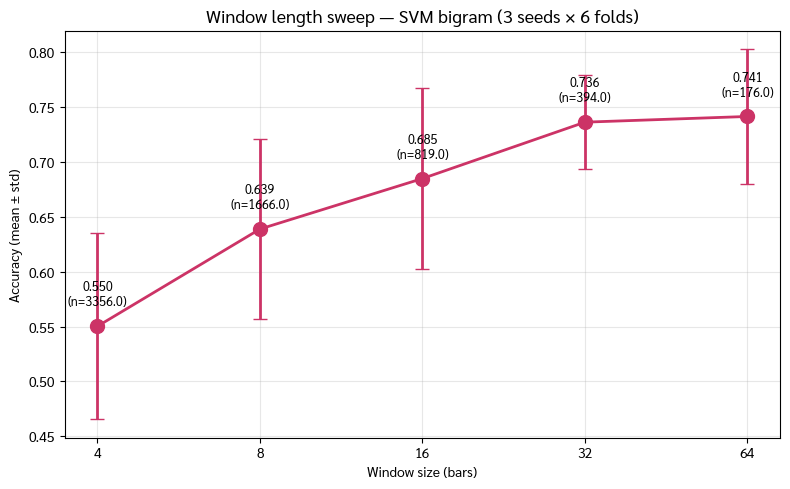

✓ saved → window_sweep.csv + window_sweep.png


In [10]:
from tqdm.notebook import tqdm

WINDOW_SIZES = [4, 8, 16, 32, 64]
sweep_results = []

for ws in tqdm(WINDOW_SIZES, desc='window sweep'):
    stride = max(1, ws // 2)  # stride = half window (50% overlap)
    win_df = build_windows(df, window_size=ws, stride=stride)
    feat_df = compute_features_dataframe(win_df)
    docs_sw = (feat_df
               .merge(win_df[['song_file', 'start_bar', 'tokens']],
                      on=['song_file', 'start_bar'])
               ['tokens']
               .apply(lambda toks: ' '.join(toks))
               .tolist())

    # Labels ตรงกับ feat_df ของ window size นี้
    labels_sw = feat_df['instrument'].map({i: idx for idx, i in enumerate(INSTRUMENTS)}).values

    docs_arr = np.array(docs_sw, dtype=object)
    fold_accs = []
    for seed in [42, 123, 2024]:
        for held_out, train_idx, test_idx in make_cv_splits(feat_df, group_col='piece'):
            X_tr = docs_arr[train_idx].tolist()
            X_te = docs_arr[test_idx].tolist()
            y_tr = labels_sw[train_idx]
            y_te = labels_sw[test_idx]

            pipe = Pipeline([
                ('vec', TfidfVectorizer(tokenizer=thai_token_split, token_pattern=None,
                                        lowercase=False, ngram_range=(1, 2))),
                ('svm', LinearSVC(C=1.0, max_iter=5000, random_state=seed))
            ])
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_te)
            fold_accs.append(accuracy_score(y_te, y_pred))

    sweep_results.append({
        'window_size': ws,
        'n_windows':   len(win_df),
        'acc_mean':    np.mean(fold_accs),
        'acc_std':     np.std(fold_accs),
    })

sweep_df = pd.DataFrame(sweep_results)
display(sweep_df.round(4))
save_table(sweep_df, 'window_sweep')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(sweep_df['window_size'], sweep_df['acc_mean'],
            yerr=sweep_df['acc_std'], marker='o', markersize=10,
            linewidth=2, capsize=5, color='#cc3366')
ax.set_xlabel('Window size (bars)')
ax.set_ylabel('Accuracy (mean ± std)')
ax.set_title('Window length sweep — SVM bigram (3 seeds × 6 folds)', fontsize=13)
ax.set_xscale('log', base=2)
ax.set_xticks(WINDOW_SIZES)
ax.set_xticklabels(WINDOW_SIZES)
ax.grid(alpha=0.3)

# Annotate
for _, r in sweep_df.iterrows():
    ax.annotate(f"{r['acc_mean']:.3f}\n(n={r['n_windows']})",
                (r['window_size'], r['acc_mean']),
                textcoords="offset points", xytext=(0, 15), ha='center', fontsize=9)

plt.tight_layout()
save_fig('window_sweep')
plt.show()
print("✓ saved → window_sweep.csv + window_sweep.png")

## 8. Consolidated results

รวมทุก baseline runs (162 rows = 9 models × 18 runs) → summary table
ranking, save CSV, plot bar chart, และ confusion matrix ของ best model

In [11]:
# Save all runs + summary
runs_df = pd.DataFrame(all_rows)
save_table(runs_df, 'all_baselines_runs')

summary = (runs_df.groupby('model')
           .agg(acc_mean=('accuracy', 'mean'),
                acc_std=('accuracy', 'std'),
                f1_mean=('macro_f1', 'mean'),
                f1_std=('macro_f1', 'std'),
                n_runs=('accuracy', 'count'))
           .round(4)
           .sort_values('acc_mean', ascending=False))
display(summary)
save_table(summary.reset_index(), 'baseline_summary')

print(f"\n✓ saved → all_baselines_runs.csv + baseline_summary.csv")

,acc_mean,acc_std,f1_mean,f1_std,n_runs
model,,,,,
6_svm_bigram,0.6848,0.0848,0.6734,0.0824,18
7_svm_trigram,0.6824,0.0871,0.6703,0.0835,18
8_xgb_combined,0.6480,0.1023,0.6296,0.0870,18
5_svm_unigram,0.6200,0.1217,0.6013,0.1197,18
2_lr_handcrafted,0.6106,0.0647,0.5798,0.0645,18
4_nb_unigram,0.6043,0.1281,0.5812,0.1386,18
3_rf_handcrafted,0.5478,0.0747,0.5271,0.0669,18
1_majority,0.2790,0.0499,0.1085,0.0146,18
0_random,0.2467,0.0279,0.2441,0.0263,18



✓ saved → all_baselines_runs.csv + baseline_summary.csv


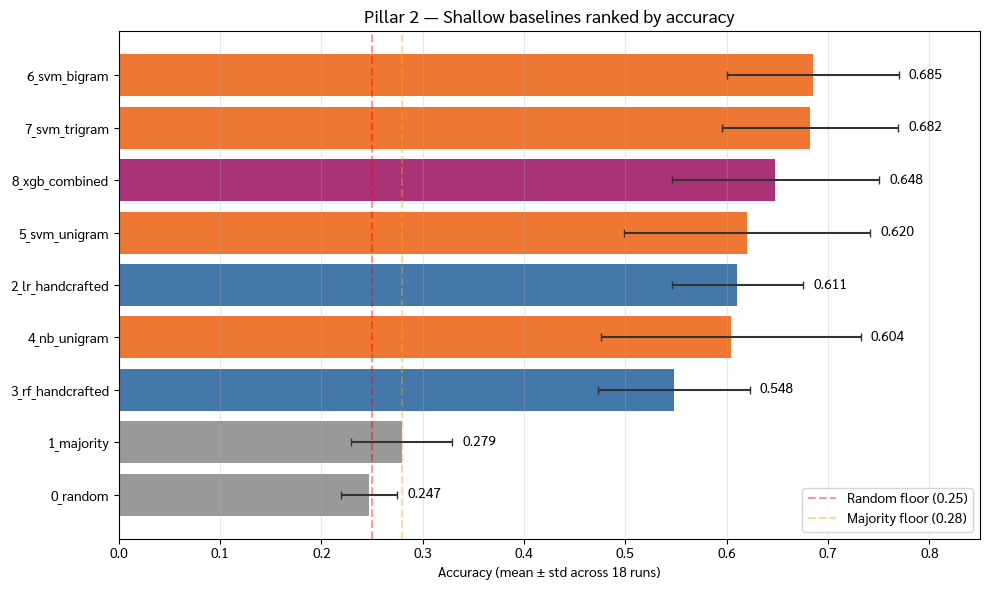

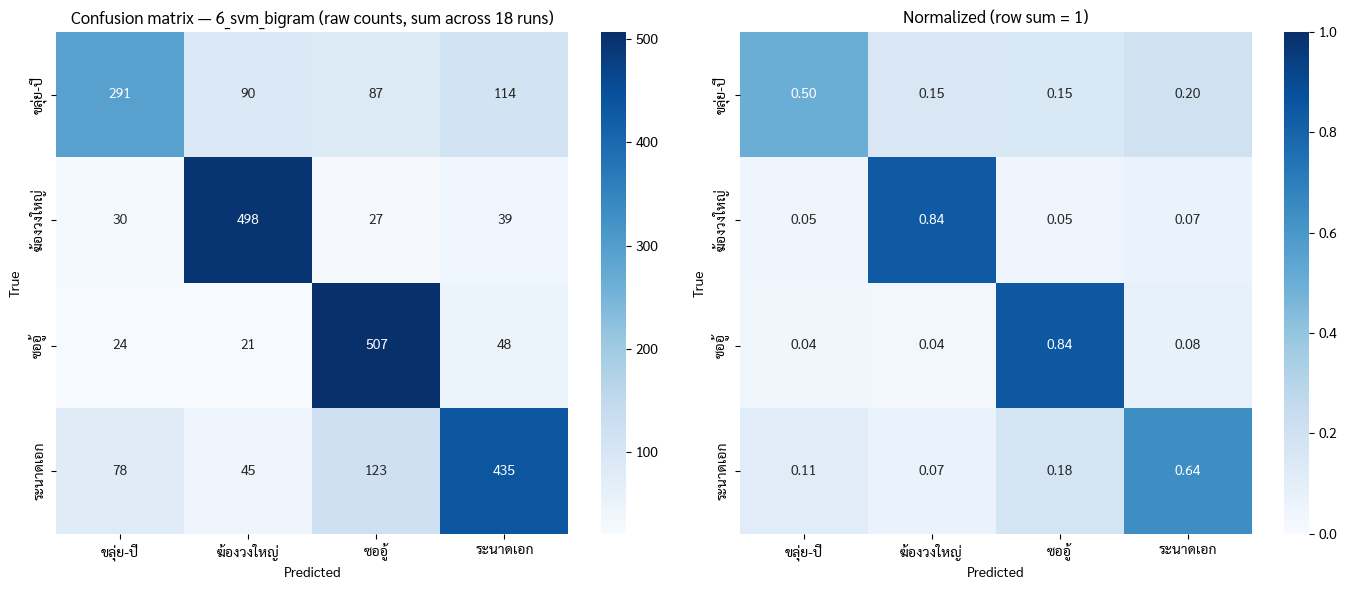

✓ saved → baseline_accuracy.png + confusion_best_baseline.png


In [12]:
# Bar chart of all baselines
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = summary.reset_index().sort_values('acc_mean')

# สีแยก: floor (random/majority) เทา, hand-crafted น้ำเงิน, n-gram ส้ม, combined ม่วง
def color_of(model_name):
    if model_name in ('0_random', '1_majority'): return '#999999'
    if 'handcrafted' in model_name:               return '#4477aa'
    if 'nb_' in model_name or 'svm_' in model_name: return '#ee7733'
    if 'xgb' in model_name:                       return '#aa3377'
    return '#cccccc'

colors = [color_of(m) for m in plot_df['model']]
bars = ax.barh(plot_df['model'], plot_df['acc_mean'],
               xerr=plot_df['acc_std'], color=colors,
               error_kw={'ecolor': '#333', 'capsize': 3})

# Annotate ค่า
for bar, acc, std in zip(bars, plot_df['acc_mean'], plot_df['acc_std']):
    ax.text(acc + std + 0.01, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=10)

# Reference lines
ax.axvline(0.25, color='red', linestyle='--', alpha=0.4, label='Random floor (0.25)')
ax.axvline(0.279, color='orange', linestyle='--', alpha=0.4, label='Majority floor (0.28)')

ax.set_xlabel('Accuracy (mean ± std across 18 runs)')
ax.set_title('Pillar 2 — Shallow baselines ranked by accuracy', fontsize=13)
ax.set_xlim(0, 0.85)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
save_fig('baseline_accuracy')
plt.show()

# Confusion matrix ของ best model
from sklearn.metrics import ConfusionMatrixDisplay

best_model = 'best: 6_svm_bigram'
conf = all_confusion['6_svm_bigram']
conf_norm = conf / conf.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw counts
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=INSTRUMENTS, yticklabels=INSTRUMENTS, ax=axes[0])
axes[0].set_title(f'Confusion matrix — 6_svm_bigram (raw counts, sum across 18 runs)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalized
sns.heatmap(conf_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=INSTRUMENTS, yticklabels=INSTRUMENTS, ax=axes[1])
axes[1].set_title('Normalized (row sum = 1)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
save_fig('confusion_best_baseline')
plt.show()
print("✓ saved → baseline_accuracy.png + confusion_best_baseline.png")

In [13]:
from sklearn.metrics import classification_report, precision_score, recall_score

# Best model = 6_svm_bigram — รวบรวม predictions ทุก fold/seed เพื่อทำ aggregated report
# วิธี: re-run best model 1 รอบ และเก็บ y_true + y_pred ของทุก fold
def collect_predictions(pipeline, docs, model_name, seeds=(42, 123, 2024)):
    """รัน CV และเก็บ y_true + y_pred รวม"""
    all_y_true, all_y_pred = [], []
    docs_arr = np.array(docs, dtype=object)

    for seed in seeds:
        for _, train_idx, test_idx in make_cv_splits(features_df, group_col='piece'):
            X_train = docs_arr[train_idx].tolist()
            X_test = docs_arr[test_idx].tolist()
            y_train = windows_labels[train_idx]
            y_test = windows_labels[test_idx]

            clf = clone(pipeline)
            for _, step in clf.steps:
                if hasattr(step, 'random_state'):
                    step.random_state = seed
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            all_y_true.extend(y_test.tolist())
            all_y_pred.extend(y_pred.tolist())

    return np.array(all_y_true), np.array(all_y_pred)

# รัน best model
best_pipeline = Pipeline([
    ('vec', TfidfVectorizer(tokenizer=thai_token_split, token_pattern=None,
                            lowercase=False, ngram_range=(1, 2))),
    ('svm', LinearSVC(C=1.0, max_iter=5000, random_state=42))
])
y_true_best, y_pred_best = collect_predictions(best_pipeline, docs, '6_svm_bigram')

# Classification report เป็น dict → DataFrame
report = classification_report(
    y_true_best, y_pred_best,
    labels=range(4), target_names=INSTRUMENTS,
    output_dict=True, zero_division=0, digits=4
)
report_df = pd.DataFrame(report).T.round(4)
print(f"Classification report — best model (6_svm_bigram)")
print(f"รวบรวม predictions จาก 18 runs ({len(y_true_best):,} predictions)")
display(report_df)

save_table(report_df.reset_index().rename(columns={'index': 'class'}),
           'classification_report_best')
print(f"\n✓ saved → classification_report_best.csv")

Classification report — best model (6_svm_bigram)
รวบรวม predictions จาก 18 runs (2,457 predictions)


,precision,recall,f1-score,support
ขลุ่ย-ปี่,0.6879,0.5000,0.5791,582.0000
ฆ้องวงใหญ่,0.7615,0.8384,0.7981,594.0000
ซออู้,0.6815,0.8450,0.7545,600.0000
ระนาดเอก,0.6840,0.6388,0.6606,681.0000
accuracy,0.7045,0.7045,0.7045,0.7045
macro avg,0.7037,0.7055,0.6981,2457.0000
weighted avg,0.7030,0.7045,0.6975,2457.0000



✓ saved → classification_report_best.csv


**Accuracy ของ 6_svm_bigram คำนวณได้ 2 แบบ — บอกคนละมิติ**

[A] Mean of folds:                          0.6848
    — เฉลี่ย accuracy ของแต่ละ fold (18 folds)
    — เฉลี่ยแบบ macro: ทุก fold น้ำหนักเท่ากัน
    — เหมาะกับ research report ที่ fold มี size ต่างกัน

[B] Micro accuracy (pooled predictions):    0.7045
    — รวม predictions ทั้งหมด 2,457 ตัว แล้วคำนวณครั้งเดียว
    — bias ไปทาง fold ที่มี samples เยอะ (สาธุการ 216 vs โหมโรง 68)
    — เหมาะกับ classification report มาตรฐานของ sklearn

ความต่าง: 0.0197 (~2%)
→ ไม่มีตัวไหนผิด แค่คำนวณคนละแบบ
→ Notebook นี้ใช้ [A] เป็นค่าหลัก เพราะ unbiased ตาม fold

,ขลุ่ย-ปี่,ฆ้องวงใหญ่,ซออู้,ระนาดเอก,macro
model,,,,,
6_svm_bigram,0.592,0.737,0.740,0.624,0.673
7_svm_trigram,0.567,0.739,0.754,0.621,0.670
8_xgb_combined,0.415,0.735,0.777,0.592,0.630
5_svm_unigram,0.456,0.692,0.723,0.534,0.601
4_nb_unigram,0.472,0.703,0.651,0.498,0.581
2_lr_handcrafted,0.385,0.743,0.746,0.444,0.580
3_rf_handcrafted,0.276,0.697,0.680,0.456,0.527
0_random,0.232,0.227,0.259,0.258,0.244
1_majority,0.000,0.000,0.000,0.434,0.109


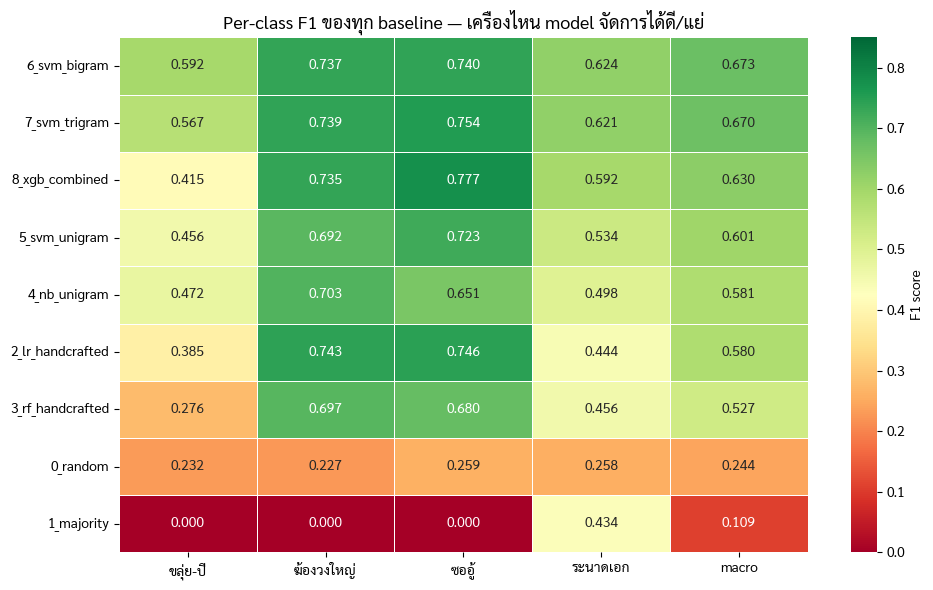

✓ saved → per_class_f1_heatmap.png + per_class_f1.csv


In [14]:
# Per-class F1 ของทุก baseline — รวมเป็น matrix ดูง่าย
per_class_f1 = (runs_df.groupby('model')
                [['f1_khlui', 'f1_khong', 'f1_so', 'f1_ranat', 'macro_f1']]
                .mean()
                .round(3)
                .sort_values('macro_f1', ascending=False))
per_class_f1.columns = ['ขลุ่ย-ปี่', 'ฆ้องวงใหญ่', 'ซออู้', 'ระนาดเอก', 'macro']
display(per_class_f1)

# Heatmap visualize
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(per_class_f1, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=0.85, cbar_kws={'label': 'F1 score'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Per-class F1 ของทุก baseline — เครื่องไหน model จัดการได้ดี/แย่', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
save_fig('per_class_f1_heatmap')
plt.show()

save_table(per_class_f1.reset_index(), 'per_class_f1')
print("✓ saved → per_class_f1_heatmap.png + per_class_f1.csv")